# MVTec AD Comprehensive EDA

Notebook ini menganalisis seluruh kategori MVTec AD dengan path dataset dari environment variable `DATA_RAW_ROOT` (tanpa hardcode).

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

data_root = Path(os.getenv("DATA_RAW_ROOT", "~/Downloads/mvtec_anomaly_detection")).expanduser()
if not data_root.exists():
    raise FileNotFoundError(f"DATA_RAW_ROOT not found: {data_root}")

print(f"DATA_RAW_ROOT: {data_root}")

DATA_RAW_ROOT: /Users/tamagoasin/Downloads/mvtec_anomaly_detection


## 1) Data Collection Audit

Audit struktur folder dan validasi kategori yang tersedia.

In [2]:
categories = sorted([p.name for p in data_root.iterdir() if p.is_dir()])
print(f"Total categories: {len(categories)}")
categories

Total categories: 15


['bottle',
 'cable',
 'capsule',
 'carpet',
 'grid',
 'hazelnut',
 'leather',
 'metal_nut',
 'pill',
 'screw',
 'tile',
 'toothbrush',
 'transistor',
 'wood',
 'zipper']

In [3]:
rows = []
for cat in categories:
    cat_dir = data_root / cat
    train_good = len(list((cat_dir / "train" / "good").glob("*.png")))
    test_root = cat_dir / "test"
    gt_root = cat_dir / "ground_truth"

    test_breakdown = {}
    test_total = 0
    if test_root.exists():
        for defect_dir in sorted([d for d in test_root.iterdir() if d.is_dir()]):
            count = len(list(defect_dir.glob("*.png")))
            test_breakdown[defect_dir.name] = count
            test_total += count

    gt_total_masks = 0
    if gt_root.exists():
        for d in sorted([x for x in gt_root.iterdir() if x.is_dir()]):
            gt_total_masks += len(list(d.glob("*.png")))

    rows.append({
        "category": cat,
        "train_good_images": train_good,
        "test_images_total": test_total,
        "test_types": len(test_breakdown),
        "ground_truth_masks_total": gt_total_masks,
        "test_breakdown": test_breakdown,
    })

df_overview = pd.DataFrame(rows).sort_values("category").reset_index(drop=True)
df_overview

,category,train_good_images,test_images_total,test_types,ground_truth_masks_total,test_breakdown
0,bottle,209,83,4,63,"{'broken_large': 20, 'broken_small': 22, 'cont..."
1,cable,224,150,9,92,"{'bent_wire': 13, 'cable_swap': 12, 'combined'..."
2,capsule,219,132,6,109,"{'crack': 23, 'faulty_imprint': 22, 'good': 23..."
3,carpet,280,117,6,89,"{'color': 19, 'cut': 17, 'good': 28, 'hole': 1..."
4,grid,264,78,6,57,"{'bent': 12, 'broken': 12, 'glue': 11, 'good':..."
5,hazelnut,391,110,5,70,"{'crack': 18, 'cut': 17, 'good': 40, 'hole': 1..."
6,leather,245,124,6,92,"{'color': 19, 'cut': 19, 'fold': 17, 'glue': 1..."
7,metal_nut,220,115,5,93,"{'bent': 25, 'color': 22, 'flip': 23, 'good': ..."
8,pill,267,167,8,141,"{'color': 25, 'combined': 17, 'contamination':..."
9,screw,320,160,6,119,"{'good': 41, 'manipulated_front': 24, 'scratch..."


## 2) Distribution Analysis

Distribusi jumlah sampel train/test untuk melihat imbalance antar kategori.

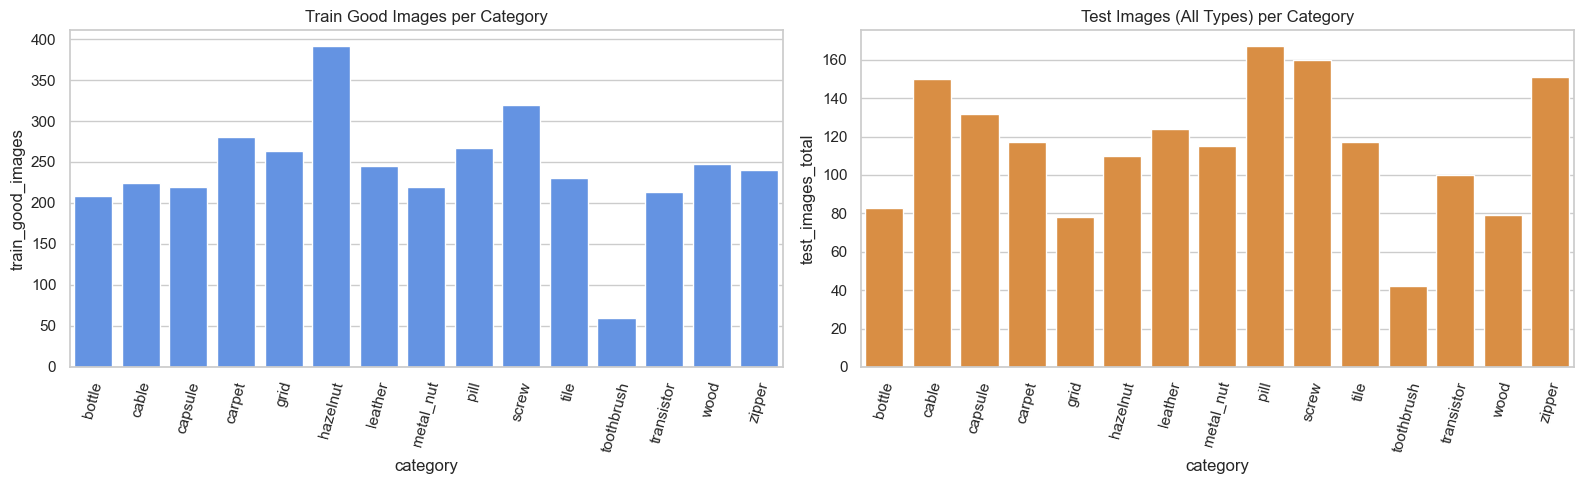

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=df_overview, x="category", y="train_good_images", ax=axes[0], color="#4f8ef7")
axes[0].set_title("Train Good Images per Category")
axes[0].tick_params(axis="x", rotation=75)

sns.barplot(data=df_overview, x="category", y="test_images_total", ax=axes[1], color="#f28e2b")
axes[1].set_title("Test Images (All Types) per Category")
axes[1].tick_params(axis="x", rotation=75)

plt.tight_layout()
plt.show()

## 3) Image Resolution & Channel Profiling

Sampling image dari train/test untuk profiling ukuran resolusi, mode warna, dan statistik pixel.

In [5]:
sample_rows = []
for cat in categories:
    for split in ["train", "test"]:
        split_dir = data_root / cat / split
        if not split_dir.exists():
            continue
        img_paths = []
        for sub in sorted([d for d in split_dir.iterdir() if d.is_dir()]):
            img_paths.extend(sorted(sub.glob("*.png"))[:10])
        for img_path in img_paths[:30]:
            with Image.open(img_path) as img:
                arr = np.array(img)
                sample_rows.append({
                    "category": cat,
                    "split": split,
                    "subtype": img_path.parent.name,
                    "width": img.width,
                    "height": img.height,
                    "mode": img.mode,
                    "mean_pixel": float(arr.mean()),
                    "std_pixel": float(arr.std()),
                })

df_image_profile = pd.DataFrame(sample_rows)
df_image_profile.head()

,category,split,subtype,width,height,mode,mean_pixel,std_pixel
0,bottle,train,good,900,900,RGB,136.868765,91.846939
1,bottle,train,good,900,900,RGB,138.549650,91.976182
2,bottle,train,good,900,900,RGB,136.569559,91.689969
3,bottle,train,good,900,900,RGB,136.231600,92.345641
4,bottle,train,good,900,900,RGB,138.857514,92.109963


width              height              mean_pixel  \
                    mean   min   max    mean   min   max        mean   
category   split                                                       
bottle     test    900.0   900   900   900.0   900   900  138.261170   
           train   900.0   900   900   900.0   900   900  136.929559   
cable      test   1024.0  1024  1024  1024.0  1024  1024  102.975933   
           train  1024.0  1024  1024  1024.0  1024  1024   97.845181   
capsule    test   1000.0  1000  1000  1000.0  1000  1000  171.721719   
           train  1000.0  1000  1000  1000.0  1000  1000  169.994565   
carpet     test   1024.0  1024  1024  1024.0  1024  1024   91.794177   
           train  1024.0  1024  1024  1024.0  1024  1024   90.908124   
grid       test   1024.0  1024  1024  1024.0  1024  1024  119.551915   
           train  1024.0  1024  1024  1024.0  1024  1024  116.640821   
hazelnut   test   1024.0  1024  1024  1024.0  1024  1024   53.871454   
           train  1024.0  1024  1024  1024.0  1024  1024   49.343486   
leather    test   1024.0  1024  1024  1024.0  1024  1024   79.767617   
           train  1024.0  1024  1024  1024.0  1024  1024   72.630132   
metal_nut  test    700.0   700   700   700.0   700   700   58.176580   
           train   700.0   700   700   700.0   700   700   54.984335   
pill       test    800.0   800   800   800.0   800   800   80.378955   
           train   800.0   800   800   800.0   800   800   79.142276   
screw      test   1024.0  1024  1024  1024.0  1024  1024  181.191179   
           train  1024.0  1024  1024  1024.0  1024  1024  185.730574   
tile       test    840.0   840   840   840.0   840   840  110.765035   
           train   840.0   840   840   840.0   840   840  119.612759   
toothbrush test   1024.0  1024  1024  1024.0  1024  1024   49.383441   
           train  1024.0  1024  1024  1024.0  1024  1024   50.622385   
transistor test   1024.0  1024  1024  1024.0  1024  1024   78.088099   
           train  1024.0  1024  1024  1024.0  1024  1024   76.115902   
wood       test   1024.0  1024  1024  1024.0  1024  1024  126.345558   
           train  1024.0  1024  1024  1024.0  1024  1024  124.418113   
zipper     test   1024.0  1024  1024  1024.0  1024  1024  101.696273   
           train  1024.0  1024  1024  1024.0  1024  1024  103.412473   

                                          std_pixel                        
                         min         max       mean        min        max  
category   split                                                           
bottle     test   134.391531  147.291749  91.329525  84.917953  93.904088  
           train  134.946192  138.857514  92.021460  91.044917  92.604927  
cable      test    86.417737  113.267346  53.026806  45.903220  56.365407  
           train   93.356698  102.730652  53.987012  51.544728  55.950732  
capsule    test   158.975234  181.005817  64.611125  60.116291  66.179791  
           train  163.088766  171.886193  64.004932  61.760265  64.706475  
carpet     test    84.986078   95.804989  34.661141  32.743579  37.015858  
           train   88.147292   96.604134  35.390540  33.575290  39.743151  
grid       test   111.522207  132.416362  38.889438  31.207934  48.774741  
           train  107.978791  122.688932  38.564423  34.275678  47.222195  
hazelnut   test    50.548285   58.269770  27.102077  22.139968  34.794540  
           train   47.172419   51.243697  26.210485  23.952228  28.307827  
leather    test    70.897892   87.172439  25.090890  21.463492  28.751900  
           train   68.414389   76.074851  21.130080  19.363659  22.385725  
metal_nut  test    52.874188   63.004836  40.222057  35.852935  45.022517  
           train   51.437581   61.596967  38.457618  35.960022  44.476884  
pill       test    78.860195   82.083869  75.250690  74.339563  76.456635  
           train   77.873756   80.464761  76.044611  74.923329  76.891457  
screw      test   168.220042  191.981136  33.2

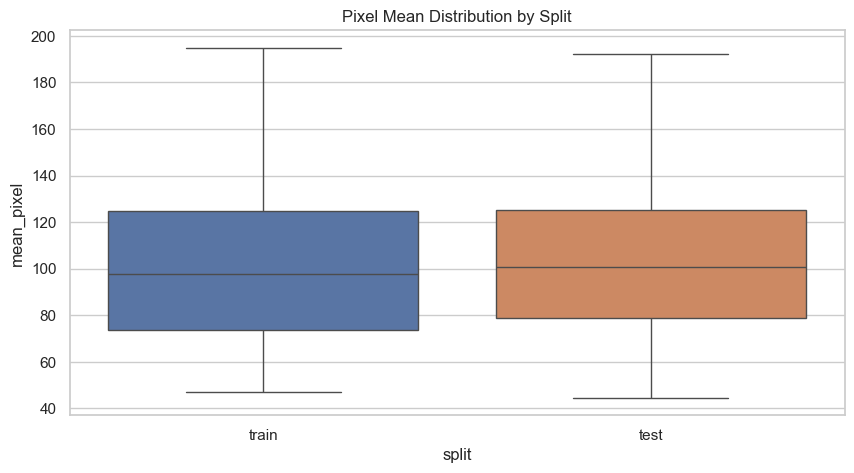

In [6]:
if not df_image_profile.empty:
    display(df_image_profile.groupby(["category", "split"])[["width", "height", "mean_pixel", "std_pixel"]].agg(["mean", "min", "max"]))

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df_image_profile, x="split", y="mean_pixel", hue="split", legend=False)
    plt.title("Pixel Mean Distribution by Split")
    plt.show()
else:
    print("No image profile rows found.")

## 4) Defect-Type Depth per Category

Memeriksa granularitas kelas defect di setiap kategori test split.

In [7]:
defect_rows = []
for _, row in df_overview.iterrows():
    cat = row["category"]
    for defect_type, count in row["test_breakdown"].items():
        defect_rows.append({"category": cat, "defect_type": defect_type, "count": count})

df_defects = pd.DataFrame(defect_rows)
df_defects.sort_values(["category", "count"], ascending=[True, False]).head(30)

,category,defect_type,count
1,bottle,broken_small,22
2,bottle,contamination,21
0,bottle,broken_large,20
3,bottle,good,20
9,cable,good,58
7,cable,cut_inner_insulation,14
4,cable,bent_wire,13
5,cable,cable_swap,12
10,cable,missing_cable,12
6,cable,combined,11


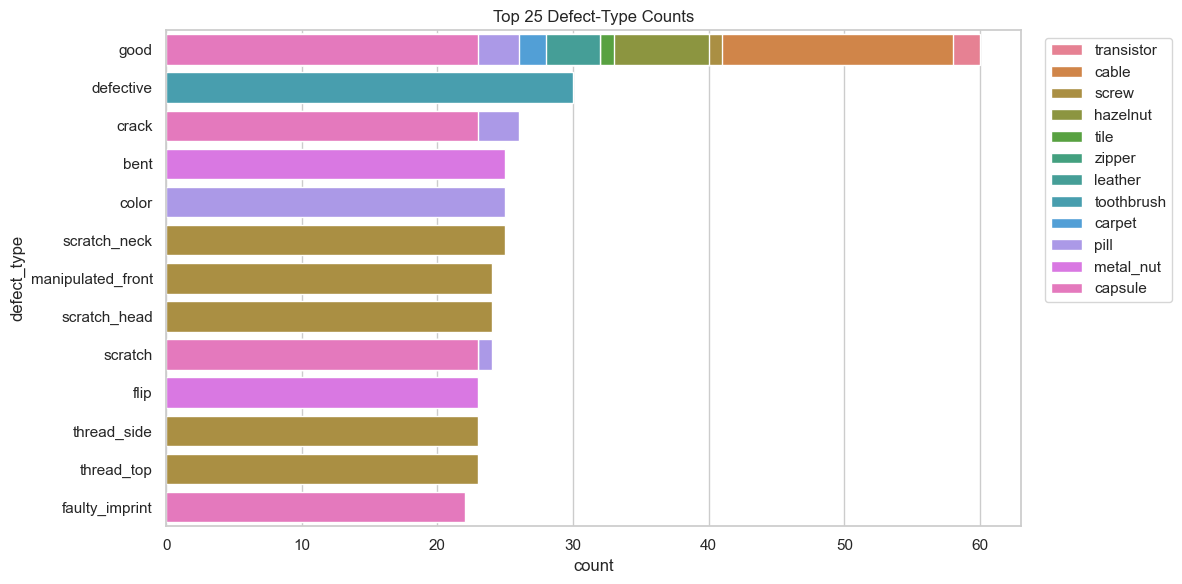

In [8]:
if not df_defects.empty:
    top_defects = df_defects.sort_values("count", ascending=False).head(25)
    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_defects, x="count", y="defect_type", hue="category", dodge=False)
    plt.title("Top 25 Defect-Type Counts")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## 5) Operational Readiness Summary

Menyusun ringkasan yang dipakai langsung untuk tahap preprocessing, training, evaluasi, deploy, dan monitoring.

In [9]:
summary = {
    "total_categories": int(len(df_overview)),
    "total_train_good_images": int(df_overview["train_good_images"].sum()),
    "total_test_images": int(df_overview["test_images_total"].sum()),
    "categories_with_gt_masks": int((df_overview["ground_truth_masks_total"] > 0).sum()),
}

summary_df = pd.DataFrame([summary])
summary_df

,total_categories,total_train_good_images,total_test_images,categories_with_gt_masks
0,15,3629,1725,15


In [10]:
print("Recommended next steps:")
print("1. Keep category-specific models (PatchCore per category).")
print("2. Use shared evaluation schema (AUROC/F1/CM) across all categories.")
print("3. Store per-category metrics in models/eval and consolidated run report in reports/model-eval.")
print("4. Deploy using active model manifest + expose telemetry endpoints for latency/quality monitoring.")

Recommended next steps:
1. Keep category-specific models (PatchCore per category).
2. Use shared evaluation schema (AUROC/F1/CM) across all categories.
3. Store per-category metrics in models/eval and consolidated run report in reports/model-eval.
4. Deploy using active model manifest + expose telemetry endpoints for latency/quality monitoring.
